# Session 06 — Estimation and confidence intervals

Lecture companion to Brooks, Chapter 6, and the instructor notes. Run the numbered code sections when the notes say **Switch to Code 1–5**. All measurements below are illustrative teaching data, not observations from a real study.

The central question: what does a sample tell us about a fixed but unknown population parameter?

## Setup

We use NumPy, SciPy, Matplotlib and statsmodels. Code 1 uses a fresh random sample each time it runs; Code 5 has a fixed seed for reproducibility.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t
from statsmodels.stats.proportion import proportion_confint

BLUE = "#174A73"
LIGHT_BLUE = "#69B6CE"
ORANGE = "#D66B20"
plt.rcParams.update({"figure.figsize": (9, 5), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

## Code 1 — Coverage is a property of the procedure

The population mean is fixed at 84 mA and the population SD is known to be 1.1 mA. We repeatedly collect a new sample of 16 independent observations, construct a 95% z interval for each sample, and count which intervals cover the fixed mean. The first 40 of the 2,000 intervals are plotted. Orange means a miss.

After discussing coverage, inspect the optional calibration-offset calculation: a fixed error shifts every interval, and more precision alone does not make the sensor correct.

Estimated coverage: 0.947 (1894 of 2000)


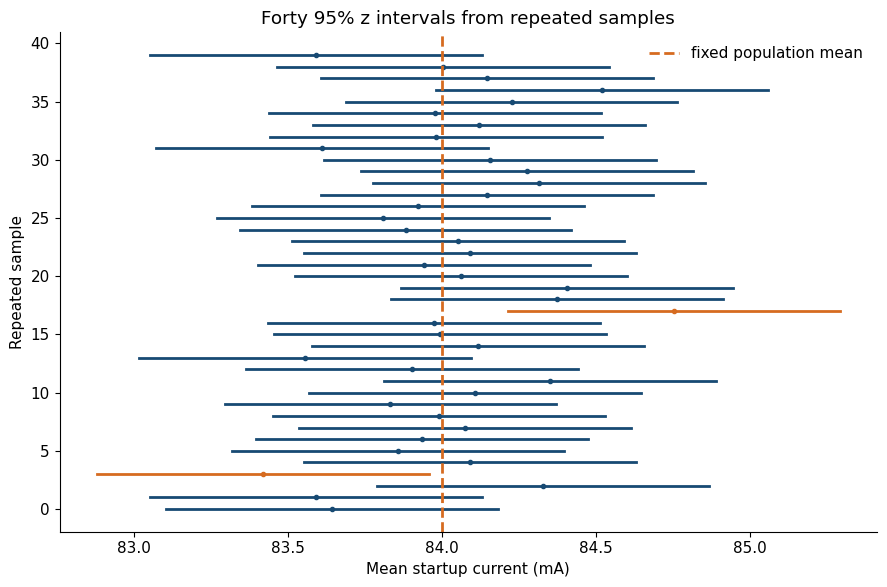

Coverage with a fixed +0.8 mA calibration error: 0.163


In [17]:
rng_coverage = np.random.default_rng()
mu_true, sigma_true = 84.0, 1.1
n_sim, repetitions = 16, 2000
samples = rng_coverage.normal(mu_true, sigma_true, size=(repetitions, n_sim))
sample_means = samples.mean(axis=1)
z_critical_coverage = norm.ppf(0.975)
half_widths = z_critical_coverage * sigma_true / np.sqrt(n_sim)
lower = sample_means - half_widths
upper = sample_means + half_widths
covers = (lower <= mu_true) & (mu_true <= upper)
print(f"Estimated coverage: {covers.mean():.3f} ({covers.sum()} of {repetitions})")

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(40):
    colour = BLUE if covers[i] else ORANGE
    ax.plot([lower[i], upper[i]], [i, i], color=colour, lw=2)
    ax.plot(sample_means[i], i, 'o', color=colour, ms=3)
ax.axvline(mu_true, color=ORANGE, ls='--', lw=2, label='fixed population mean')
ax.set(xlabel='Mean startup current (mA)', ylabel='Repeated sample',
       title='Forty 95% z intervals from repeated samples')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Optional: the measuring device reads 0.8 mA too high every time.
offset = 0.8
biased_covers = ((lower + offset) <= mu_true) & (mu_true <= (upper + offset))
print(f"Coverage with a fixed +{offset:.1f} mA calibration error: "
      f"{biased_covers.mean():.3f}")

## Code 2 — A t interval from one observed sample

Illustrative startup-current measurements (mA) from 16 prototype devices. The target is the **population mean** current under the same operating conditions. Population SD is unknown, so calculate the sample SD with ddof=1 and use a t critical value with 15 degrees of freedom.

In [18]:
current_ma = np.array([82.4, 84.1, 83.7, 85.2, 82.9, 84.8, 86.0, 83.5,
                       84.4, 85.1, 83.9, 84.6, 82.7, 85.5, 83.2, 84.9])
n = current_ma.size
xbar = current_ma.mean()
s = current_ma.std(ddof=1)
se = s / np.sqrt(n)
df = n - 1
critical = t.ppf(0.975, df=df)
margin = critical * se
t_interval = (xbar - margin, xbar + margin)
scipy_interval = t.interval(0.95, df=df, loc=xbar, scale=se)

print(f"n={n}, mean={xbar:.3f} mA, sample SD={s:.3f} mA")
print(f"SE={se:.3f} mA, t critical={critical:.3f}, margin={margin:.3f} mA")
print(f"95% t interval for the population mean: {t_interval[0]:.3f} to {t_interval[1]:.3f} mA")
print(f"SciPy check: {scipy_interval[0]:.3f} to {scipy_interval[1]:.3f} mA")
assert np.allclose(t_interval, scipy_interval)

n=16, mean=84.181 mA, sample SD=1.058 mA
SE=0.265 mA, t critical=2.131, margin=0.564 mA
95% t interval for the population mean: 83.617 to 84.745 mA
SciPy check: 83.617 to 84.745 mA


## Code 3 — Confidence, sample size, and width

Keep the observed SD as a *planning assumption* while varying confidence and hypothetical sample size. These are hypothetical widths: we are not pretending to have collected new observations. Finally, calculate the sample size required for a target margin of error using a credible planning SD.

90% confidence, n=16: width = 0.928 mA
95% confidence, n=16: width = 1.128 mA
99% confidence, n=16: width = 1.559 mA


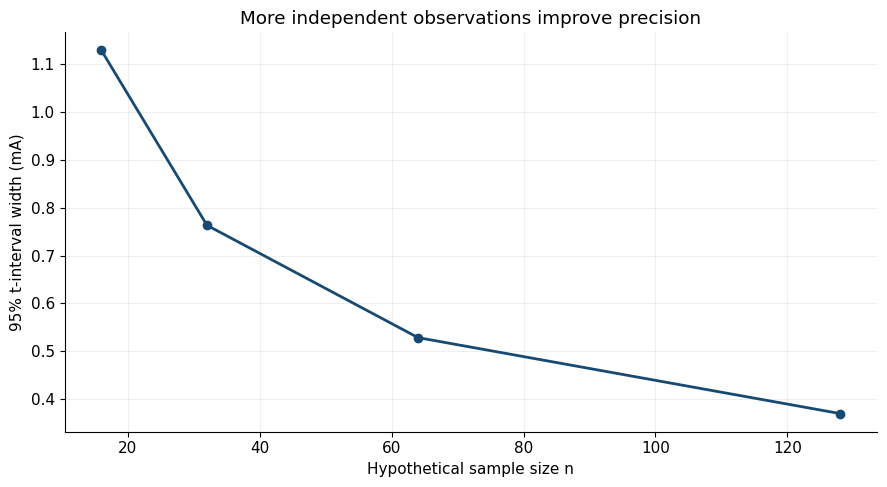

Approximate planned n for margin <= 0.5 mA: 19


In [19]:
for confidence in (0.90, 0.95, 0.99):
    q = t.ppf((1 + confidence) / 2, df=n - 1)
    width = 2 * q * s / np.sqrt(n)
    print(f"{confidence:.0%} confidence, n={n}: width = {width:.3f} mA")

hypothetical_n = np.array([16, 32, 64, 128])
hypothetical_width = 2 * t.ppf(0.975, df=hypothetical_n - 1) * s / np.sqrt(hypothetical_n)
fig, ax = plt.subplots()
ax.plot(hypothetical_n, hypothetical_width, 'o-', color=BLUE, lw=2)
ax.set(xlabel='Hypothetical sample size n', ylabel='95% t-interval width (mA)',
       title='More independent observations improve precision')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

sigma_plan = 1.1  # plausible historical/pilot SD in mA, NOT known population SD
target_margin = 0.5  # mA
z_critical = norm.ppf(0.975)
n_required = int(np.ceil((z_critical * sigma_plan / target_margin)**2))
print(f"Approximate planned n for margin <= {target_margin:.1f} mA: {n_required}")

## Code 4 — A rare-event proportion: Wald versus Wilson

Suppose none of 20 independently tested units failed under the same conditions. The target is the stable failure probability p, not the probability that any *particular* tested unit was faulty. The plug-in Wald standard error is zero when the observed proportion is zero; Wilson retains uncertainty.

In [ ]:
failures, tested = 0, 20
p_hat = failures / tested
z = norm.ppf(0.975)
wald_se = np.sqrt(p_hat * (1 - p_hat) / tested)
wald_interval = (p_hat - z * wald_se, p_hat + z * wald_se)
wilson_interval = proportion_confint(failures, tested, alpha=0.05, method='wilson')
print(f"Observed failure proportion: {p_hat:.3f}")
print(f"Wald 95%:   [{wald_interval[0]:.3f}, {wald_interval[1]:.3f}]")
print(f"Wilson 95%: [{wilson_interval[0]:.3f}, {wilson_interval[1]:.3f}]")
print('Use Wilson in the practical report; zero observed failures is not proof that p=0.')

## Code 5 — Bootstrap as a computational check

Resample the 16 observed values **with replacement**, compute a mean for each bootstrap sample, and use the 2.5% and 97.5% quantiles. The comparison with the t interval is descriptive. Bootstrap resampling does not repair a biased or unrepresentative original sample.

In [ ]:
rng_boot = np.random.default_rng(6026)
bootstrap_samples = rng_boot.choice(current_ma, size=(5000, n), replace=True)
bootstrap_means = bootstrap_samples.mean(axis=1)
bootstrap_interval = np.quantile(bootstrap_means, [0.025, 0.975])
print(f"Bootstrap percentile interval: [{bootstrap_interval[0]:.3f}, {bootstrap_interval[1]:.3f}] mA")
print(f"t interval:                    [{t_interval[0]:.3f}, {t_interval[1]:.3f}] mA")

fig, ax = plt.subplots()
ax.hist(bootstrap_means, bins=35, color=LIGHT_BLUE, edgecolor=BLUE, alpha=0.8)
ax.axvline(bootstrap_interval[0], color=ORANGE, lw=2, ls='--', label='bootstrap limits')
ax.axvline(bootstrap_interval[1], color=ORANGE, lw=2, ls='--')
ax.axvline(xbar, color=BLUE, lw=2, label='observed sample mean')
ax.set(xlabel='Bootstrap sample mean (mA)', ylabel='Count',
       title='Bootstrap distribution of the mean')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()